# 🌿 Comparación de Arquitecturas — PlantVillage

Este notebook centraliza y compara los resultados de las **5 arquitecturas** entrenadas:

| # | Arquitectura | Tipo | Fuente de métricas |
|---|---|---|---|
| 1 | MobileNetV2 | Transfer Learning | Evaluación directa `.h5` |
| 2 | ResNet50V2 | Transfer Learning | Evaluación directa `.h5` |
| 3 | EfficientNetB3 | Transfer Learning | `efficientnetb3_metricas.json` |
| 4 | DenseNet121 | Transfer Learning | `densenet121_metricas.json` |
| 5 | AgroVisionNet-Lite | Arquitectura propia | `test_metrics.json` + `classification_report.json` |

---
**⚠️ Ajusta las rutas en la sección de configuración antes de ejecutar.**
Los modelos ResNet50V2 y MobileNetV2 se evalúan directamente sobre el dataset PlantVillage
usando sus archivos `.h5`; el resto usa métricas precalculadas en JSON.

## 1. Instalación y librerías

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2. Configuración de rutas

- **ResNet50V2 y MobileNetV2**: evaluados directamente desde su archivo `.h5`.
- **EfficientNetB3, DenseNet121, AgroVisionNet-Lite**: cargados desde JSON de métricas.

Ajusta cada ruta antes de ejecutar.

In [3]:
import os

# ── Modelos evaluados desde .h5 ──────────────────────────────────────────────
MODELOS_H5 = {
    'ResNet50V2':  r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\modelos\resnet50v2_best_model.h5',
    'MobileNetV2': r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\modelos\mobilenet_best_model.h5',
}

IMG_SIZE_H5 = {
    'ResNet50V2':  224,
    'MobileNetV2': 224,
}

DATASET_DIR = r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\dataset_split\test'

EVAL_FRACTION = 1.0

# ── Modelos cargados desde JSON ───────────────────────────────────────────────
RUTAS_JSON = {
    'EfficientNetB3':     r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\metricas\efficientnetb3_metricas.json',
    'DenseNet121':        r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\metricas\densenet121_metricas.json',
    'AgroVisionNet-Lite': r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\metricas\metricas_modeloarquitecturapropia.json',
}

OUTPUT_DIR = r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Verificación ──────────────────────────────────────────────────────────────
print('Rutas configuradas.')
print('\n── Modelos .h5 ──')
for nombre, ruta in MODELOS_H5.items():
    existe = '✅' if os.path.exists(ruta) else '❌ NO ENCONTRADO'
    print(f'  {nombre:<14}: {existe}  →  {ruta}')
print(f'  Dataset     : {"✅" if os.path.isdir(DATASET_DIR) else "❌ NO ENCONTRADO"}  →  {DATASET_DIR}')
print('\n── Modelos JSON ──')
for nombre, ruta in RUTAS_JSON.items():
    existe = '✅' if os.path.exists(ruta) else '❌ NO ENCONTRADO'
    print(f'  {nombre:<22}: {existe}  →  {ruta}')

Rutas configuradas.

── Modelos .h5 ──
  ResNet50V2    : ✅  →  C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\modelos\resnet50v2_best_model.h5
  MobileNetV2   : ✅  →  C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\modelos\mobilenet_best_model.h5
  Dataset     : ✅  →  C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\dataset_split\test

── Modelos JSON ──
  EfficientNetB3        : ✅  →  C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\metricas\efficientnetb3_metricas.json
  DenseNet121           : ✅  →  C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\metricas\densenet121_metricas.json
  AgroVisionNet-Lite    : ✅  →  C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\metricas\metricas_modeloarquitecturapropia.json


## 3. Carga y normalización de métricas

La estrategia de carga varía por modelo:
- **ResNet50V2, MobileNetV2** → evaluación directa sobre el dataset con el archivo `.h5`
- **EfficientNetB3, DenseNet121, AgroVisionNet-Lite** → lectura de archivos JSON de métricas

## 3a. Evaluación directa desde modelos .h5 (ResNet50V2 y MobileNetV2)

Se carga el dataset con `tf.keras.utils.image_dataset_from_directory`, se infieren las clases
automáticamente y se calculan accuracy, loss, precision/recall/F1 macro y AUC.

In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    log_loss, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
import numpy as np


def evaluar_modelo_h5(nombre, ruta_h5, dataset_dir, img_size, batch_size=32, eval_fraction=1.0):
    """
    Carga un modelo .h5, construye un ImageDataset desde dataset_dir
    y calcula métricas completas.

    Parámetros
    ----------
    nombre        : str   — nombre identificador del modelo
    ruta_h5       : str   — ruta al archivo .h5
    dataset_dir   : str   — directorio raíz con subcarpetas por clase
    img_size      : int   — lado del cuadro de redimensionado (e.g. 224)
    batch_size    : int   — lote para inferencia
    eval_fraction : float — fracción aleatoria del dataset (1.0 = todo)
    """
    print(f'\n[{nombre}] Cargando modelo desde {ruta_h5} ...')
    model = load_model(ruta_h5)
    print(f'[{nombre}] Modelo cargado. Parámetros totales: {model.count_params():,}')

    # ── Dataset ──────────────────────────────────────────────────────────────
    print(f'[{nombre}] Leyendo dataset desde {dataset_dir} ...')
    ds_full = tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        image_size=(img_size, img_size),
        batch_size=batch_size,
        shuffle=True,
        seed=42,
        label_mode='int',
    )
    clases = ds_full.class_names
    num_clases = len(clases)
    print(f'[{nombre}] Clases detectadas: {num_clases}')

    # Seleccionar fracción si se pide
    total_batches = tf.data.experimental.cardinality(ds_full).numpy()
    n_batches = max(1, int(total_batches * eval_fraction))
    ds_eval = ds_full.take(n_batches).prefetch(tf.data.AUTOTUNE)

    # ── Inferencia ───────────────────────────────────────────────────────────
    print(f'[{nombre}] Ejecutando inferencia ({n_batches} lotes) ...')
    y_true_all, y_pred_proba_all = [], []

    for imgs, labels in ds_eval:
        # Normalización a [0,1] — ajusta si tu modelo espera otro rango
        imgs_norm = tf.cast(imgs, tf.float32) / 255.0
        preds = model(imgs_norm, training=False)          # (batch, num_clases)
        y_true_all.append(labels.numpy())
        y_pred_proba_all.append(preds.numpy())

    y_true  = np.concatenate(y_true_all)
    y_proba = np.concatenate(y_pred_proba_all)
    y_pred  = np.argmax(y_proba, axis=1)

    # ── Métricas ─────────────────────────────────────────────────────────────
    acc    = accuracy_score(y_true, y_pred)
    loss   = log_loss(y_true, y_proba)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    macro_p  = report['macro avg']['precision']
    macro_r  = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']
    w_f1     = report['weighted avg']['f1-score']

    # AUC multiclase (OvR)
    try:
        y_bin = label_binarize(y_true, classes=list(range(num_clases)))
        auc_macro = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
    except Exception as e:
        print(f'  [advertencia AUC] {e}')
        auc_macro = None

    print(f'[{nombre}] Accuracy: {acc:.4f} | Loss: {loss:.4f} | F1 macro: {macro_f1:.4f}')

    return {
        'modelo':             nombre,
        'val_accuracy':       acc,
        'val_loss':           loss,
        'macro_precision':    macro_p,
        'macro_recall':       macro_r,
        'macro_f1':           macro_f1,
        'weighted_f1':        w_f1,
        'auc_macro':          auc_macro,
        'epocas_entrenadas':  None,   # No disponible desde .h5
        'parametros_totales': model.count_params(),
        'num_clases':         num_clases,
    }


# ── Ejecutar evaluación para cada modelo .h5 ─────────────────────────────────
registros_h5 = []

for nombre_modelo, ruta_h5 in MODELOS_H5.items():
    try:
        reg = evaluar_modelo_h5(
            nombre      = nombre_modelo,
            ruta_h5     = ruta_h5,
            dataset_dir = DATASET_DIR,
            img_size    = IMG_SIZE_H5[nombre_modelo],
            batch_size  = 32,
            eval_fraction = EVAL_FRACTION,
        )
        registros_h5.append(reg)
        print(f'✅ {nombre_modelo} evaluado correctamente')
    except Exception as e:
        print(f'❌ {nombre_modelo}: error — {e}')

print(f'\nModelos .h5 evaluados: {len(registros_h5)}')



[ResNet50V2] Cargando modelo desde C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\modelos\resnet50v2_best_model.h5 ...


[ResNet50V2] Modelo cargado. Parámetros totales: 24,758,311
[ResNet50V2] Leyendo dataset desde C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\dataset_split\test ...
Found 8351 files belonging to 39 classes.
[ResNet50V2] Clases detectadas: 39
[ResNet50V2] Ejecutando inferencia (261 lotes) ...
[ResNet50V2] Accuracy: 0.8076 | Loss: 0.6995 | F1 macro: 0.7486
✅ ResNet50V2 evaluado correctamente

[MobileNetV2] Cargando modelo desde C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\modelos\mobilenet_best_model.h5 ...


[MobileNetV2] Modelo cargado. Parámetros totales: 3,058,279
[MobileNetV2] Leyendo dataset desde C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\dataset_split\test ...
Found 8351 files belonging to 39 classes.
[MobileNetV2] Clases detectadas: 39
[MobileNetV2] Ejecutando inferencia (261 lotes) ...
[MobileNetV2] Accuracy: 0.8059 | Loss: 0.6624 | F1 macro: 0.7516
✅ MobileNetV2 evaluado correctamente

Modelos .h5 evaluados: 2


In [4]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    log_loss, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
import numpy as np


def evaluar_modelo_h5(nombre, ruta_h5, dataset_dir, img_size, batch_size=32, eval_fraction=1.0):
    """
    Carga un modelo .h5, construye un ImageDataset desde dataset_dir
    y calcula métricas completas.

    Parámetros
    ----------
    nombre        : str   — nombre identificador del modelo
    ruta_h5       : str   — ruta al archivo .h5
    dataset_dir   : str   — directorio raíz con subcarpetas por clase
    img_size      : int   — lado del cuadro de redimensionado (e.g. 224)
    batch_size    : int   — lote para inferencia
    eval_fraction : float — fracción aleatoria del dataset (1.0 = todo)
    """
    print(f'\n[{nombre}] Cargando modelo desde {ruta_h5} ...')
    model = load_model(ruta_h5)
    print(f'[{nombre}] Modelo cargado. Parámetros totales: {model.count_params():,}')

    # ── Dataset ──────────────────────────────────────────────────────────────
    print(f'[{nombre}] Leyendo dataset desde {dataset_dir} ...')
    ds_full = tf.keras.utils.image_dataset_from_directory(
        dataset_dir,
        image_size=(img_size, img_size),
        batch_size=batch_size,
        shuffle=True,
        seed=42,
        label_mode='int',
    )
    clases = ds_full.class_names
    num_clases = len(clases)
    print(f'[{nombre}] Clases detectadas: {num_clases}')

    # Seleccionar fracción si se pide
    total_batches = tf.data.experimental.cardinality(ds_full).numpy()
    n_batches = max(1, int(total_batches * eval_fraction))
    ds_eval = ds_full.take(n_batches).prefetch(tf.data.AUTOTUNE)

    # ── Inferencia ───────────────────────────────────────────────────────────
    print(f'[{nombre}] Ejecutando inferencia ({n_batches} lotes) ...')
    y_true_all, y_pred_proba_all = [], []

    for imgs, labels in ds_eval:
        # Normalización a [0,1] — ajusta si tu modelo espera otro rango
        imgs_norm = tf.cast(imgs, tf.float32) / 255.0
        preds = model(imgs_norm, training=False)          # (batch, num_clases)
        y_true_all.append(labels.numpy())
        y_pred_proba_all.append(preds.numpy())

    y_true  = np.concatenate(y_true_all)
    y_proba = np.concatenate(y_pred_proba_all)
    y_pred  = np.argmax(y_proba, axis=1)

    # ── Métricas ─────────────────────────────────────────────────────────────
    acc    = accuracy_score(y_true, y_pred)
    loss   = log_loss(y_true, y_proba)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    macro_p  = report['macro avg']['precision']
    macro_r  = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']
    w_f1     = report['weighted avg']['f1-score']

    # AUC multiclase (OvR)
    try:
        y_bin = label_binarize(y_true, classes=list(range(num_clases)))
        auc_macro = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
    except Exception as e:
        print(f'  [advertencia AUC] {e}')
        auc_macro = None

    print(f'[{nombre}] Accuracy: {acc:.4f} | Loss: {loss:.4f} | F1 macro: {macro_f1:.4f}')

    return {
        'modelo':             nombre,
        'val_accuracy':       acc,
        'val_loss':           loss,
        'macro_precision':    macro_p,
        'macro_recall':       macro_r,
        'macro_f1':           macro_f1,
        'weighted_f1':        w_f1,
        'auc_macro':          auc_macro,
        'epocas_entrenadas':  None,   # No disponible desde .h5
        'parametros_totales': model.count_params(),
        'num_clases':         num_clases,
    }


# ── Ejecutar evaluación para cada modelo .h5 ─────────────────────────────────
ruta_cache = r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\cache_h5.json'

with open(ruta_cache, 'r') as f:
    registros_h5 = json.load(f)
print(f'✅ {len(registros_h5)} modelos cargados desde cache')


✅ 2 modelos cargados desde cache


## 3b. Carga de métricas desde JSON (EfficientNetB3, DenseNet121, AgroVisionNet-Lite)
```
# — esto es solo el título; la celda de código está abajo —
```


In [5]:
def cargar_metricas_standard(ruta, nombre):
    """Carga métricas desde JSON (EfficientNet, DenseNet, etc.)."""
    with open(ruta, 'r') as f:
        m = json.load(f)
    return {
        'modelo':             nombre,
        'val_accuracy':       m.get('val_accuracy', None),
        'val_loss':           m.get('val_loss', None),
        'macro_precision':    m.get('macro_avg_precision', None),
        'macro_recall':       m.get('macro_avg_recall', None),
        'macro_f1':           m.get('macro_avg_f1', None),
        'weighted_f1':        m.get('weighted_avg_f1', None),
        'auc_macro':          m.get('auc_macro', None),
        'epocas_entrenadas':  m.get('epocas_entrenadas', None),
        'parametros_totales': m.get('parametros_totales', None),
        'num_clases':         m.get('num_clases', None),
    }

# ── Cargar modelos desde JSON ─────────────────────────────────────────────────
registros_json = []

for nombre, ruta in RUTAS_JSON.items():
    try:
        reg = cargar_metricas_standard(ruta, nombre)
        registros_json.append(reg)
        print(f'✅ {nombre} cargado desde JSON')
    except FileNotFoundError as e:
        print(f'❌ {nombre}: archivo no encontrado — {e}')
    except Exception as e:
        print(f'❌ {nombre}: error — {e}')

# ── Unificar todos los registros ──────────────────────────────────────────────
registros = registros_h5 + registros_json
df = pd.DataFrame(registros)

print(f'\n✅ Total modelos en comparación: {len(df)}')
print('   Fuente de cada modelo:')
for _, row in df.iterrows():
    fuente = '.h5 (evaluación directa)' if row['modelo'] in MODELOS_H5 else 'JSON (métricas precalculadas)'
    print(f'   • {row["modelo"]:<22} → {fuente}')

✅ EfficientNetB3 cargado desde JSON
✅ DenseNet121 cargado desde JSON
✅ AgroVisionNet-Lite cargado desde JSON

✅ Total modelos en comparación: 5
   Fuente de cada modelo:
   • ResNet50V2             → .h5 (evaluación directa)
   • MobileNetV2            → .h5 (evaluación directa)
   • EfficientNetB3         → JSON (métricas precalculadas)
   • DenseNet121            → JSON (métricas precalculadas)
   • AgroVisionNet-Lite     → JSON (métricas precalculadas)


## 4. Tabla de resultados

In [18]:
import json

# Guardar registros_h5 en disco para no re-evaluar
ruta_cache = r'C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\cache_h5.json'
with open(ruta_cache, 'w') as f:
    json.dump(registros_h5, f, indent=2, default=str)
print(f'✅ Cache guardado en {ruta_cache}')

✅ Cache guardado en C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\cache_h5.json


In [8]:
import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib==3.9.4'], check=True)

CompletedProcess(args=['c:\\Users\\yenny\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'pip', 'install', 'matplotlib==3.9.4'], returncode=0)

In [11]:
import subprocess, sys
result = subprocess.run(
    [r'c:\Users\yenny\AppData\Local\Programs\Python\Python311\python.exe',
     '-m', 'pip', 'install', 'matplotlib==3.9.4', '--target',
     r'c:\Users\yenny\AppData\Local\Programs\Python\Python311\Lib\site-packages'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

  Using cached matplotlib-3.9.4-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached matplotlib-3.9.4-cp311-cp311-win_amd64.whl (7.8 MB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 22.3 MB/s  0:00:00
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached packaging-26.2-py3-none-any.whl (100 kB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------- -------------------------------- 1.3/7.1 MB 7.4 MB/s eta 0:00:01
   ------------- -------------------------- 2.4/7.1 MB 5.0 MB/s eta 0:00:01
   ---------------------------- ----------- 5.0/7.1 MB 8.6 MB/s eta 0:00:01
   -------------------

In [1]:
import matplotlib
print(matplotlib.__version__)  # debe decir 3.9.4

3.9.4


In [6]:
import matplotlib
print(matplotlib.__version__)

3.8.4


In [6]:
# Columnas a mostrar (redondear a 4 decimales)
cols_display = [
    'modelo', 'val_accuracy', 'val_loss',
    'macro_precision', 'macro_recall', 'macro_f1',
    'weighted_f1', 'auc_macro', 'epocas_entrenadas'
]

df_display = df[cols_display].copy()
for col in cols_display[1:]:
    df_display[col] = pd.to_numeric(df_display[col], errors='coerce').round(4)

df_display = df_display.sort_values('val_accuracy', ascending=False).reset_index(drop=True)

# Renombrar columnas para mejor lectura
df_display.columns = [
    'Modelo', 'Val Accuracy', 'Val Loss',
    'Precision (macro)', 'Recall (macro)', 'F1 (macro)',
    'F1 (weighted)', 'AUC (macro)', 'Épocas'
]

print('=== RESULTADOS ORDENADOS POR ACCURACY (mayor a menor) ===')
display(df_display.style
    .background_gradient(subset=['Val Accuracy', 'F1 (macro)', 'F1 (weighted)', 'AUC (macro)'],
                         cmap='YlGn')
    .background_gradient(subset=['Val Loss'], cmap='YlOrRd_r')
    .format(na_rep='—', precision=4)
    .set_caption('Comparación de arquitecturas — PlantVillage')
)

=== RESULTADOS ORDENADOS POR ACCURACY (mayor a menor) ===


,Modelo,Val Accuracy,Val Loss,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),AUC (macro),Épocas
0,EfficientNetB3,0.9958,0.0166,0.9949,0.9940,0.9944,0.9958,1.0000,20.0000
1,DenseNet121,0.9884,0.1042,0.9870,0.9825,0.9845,0.9884,1.0000,20.0000
2,AgroVisionNet-Lite,0.9249,0.2480,0.9157,0.9164,0.9104,0.9245,0.9991,—
3,ResNet50V2,0.8076,0.6995,0.8470,0.7532,0.7486,0.8032,0.9933,—
4,MobileNetV2,0.8059,0.6624,0.8652,0.7514,0.7516,0.7870,0.9964,—


## 5. Gráficas de comparación

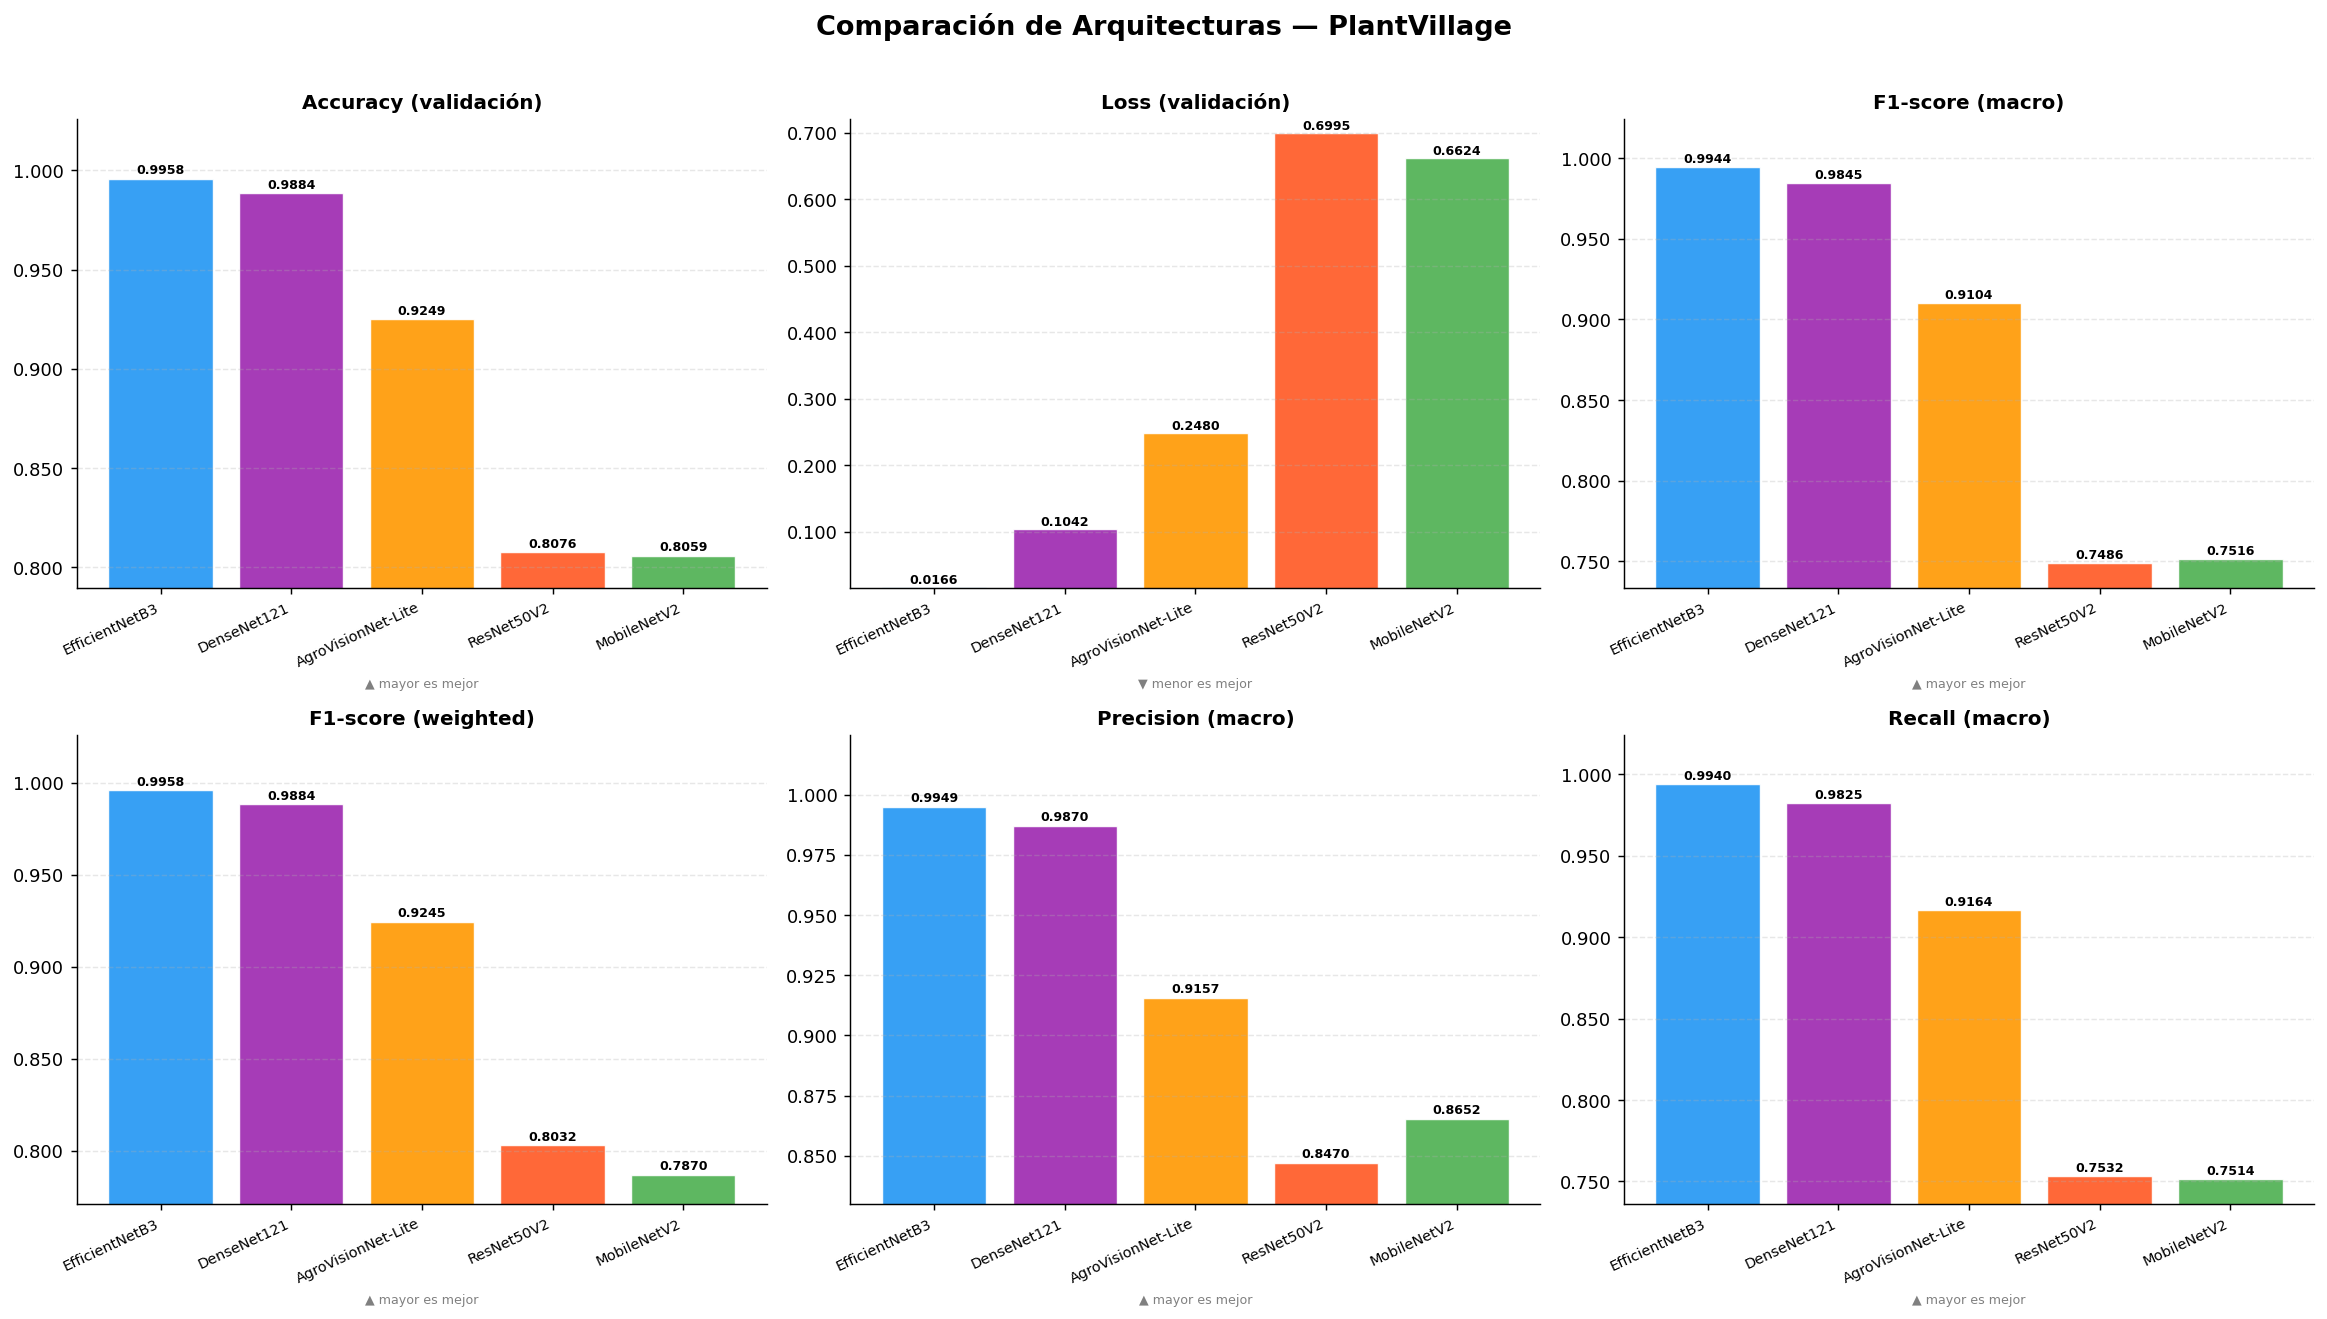

Guardado: C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\comparacion_metricas.png


In [7]:
# Paleta de colores por modelo
COLORES = {
    'MobileNetV2':        '#4CAF50',
    'EfficientNetB3':     '#2196F3',
    'ResNet50V2':          '#FF5722',
    'DenseNet121':        '#9C27B0',
    'AgroVisionNet-Lite': '#FF9800',
}

df_sorted = df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
colores_lista = [COLORES.get(m, '#607D8B') for m in df_sorted['modelo']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación de Arquitecturas — PlantVillage', fontsize=15, fontweight='bold', y=1.01)

metricas_plot = [
    ('val_accuracy',    'Accuracy (validación)',  True),
    ('val_loss',        'Loss (validación)',       False),
    ('macro_f1',        'F1-score (macro)',        True),
    ('weighted_f1',     'F1-score (weighted)',     True),
    ('macro_precision', 'Precision (macro)',       True),
    ('macro_recall',    'Recall (macro)',          True),
]

for ax, (col, titulo, mayor_mejor) in zip(axes.flatten(), metricas_plot):
    valores = pd.to_numeric(df_sorted[col], errors='coerce')
    bars = ax.bar(df_sorted['modelo'], valores, color=colores_lista,
                  edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xticklabels(df_sorted['modelo'], rotation=25, ha='right', fontsize=8)
    ax.set_ylim([valores.dropna().min() * 0.98 if valores.dropna().min() > 0 else 0,
                 valores.dropna().max() * 1.03])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    # Etiquetas en barras
    for bar, val in zip(bars, valores):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    # Indicar mejor
    arrow = '▲ mayor es mejor' if mayor_mejor else '▼ menor es mejor'
    ax.set_xlabel(arrow, fontsize=7, color='gray')

plt.tight_layout()
ruta_fig1 = os.path.join(OUTPUT_DIR, 'comparacion_metricas.png')
plt.savefig(ruta_fig1, bbox_inches='tight', dpi=150)
plt.show()
print(f'Guardado: {ruta_fig1}')

## 6. Radar chart (visión global)

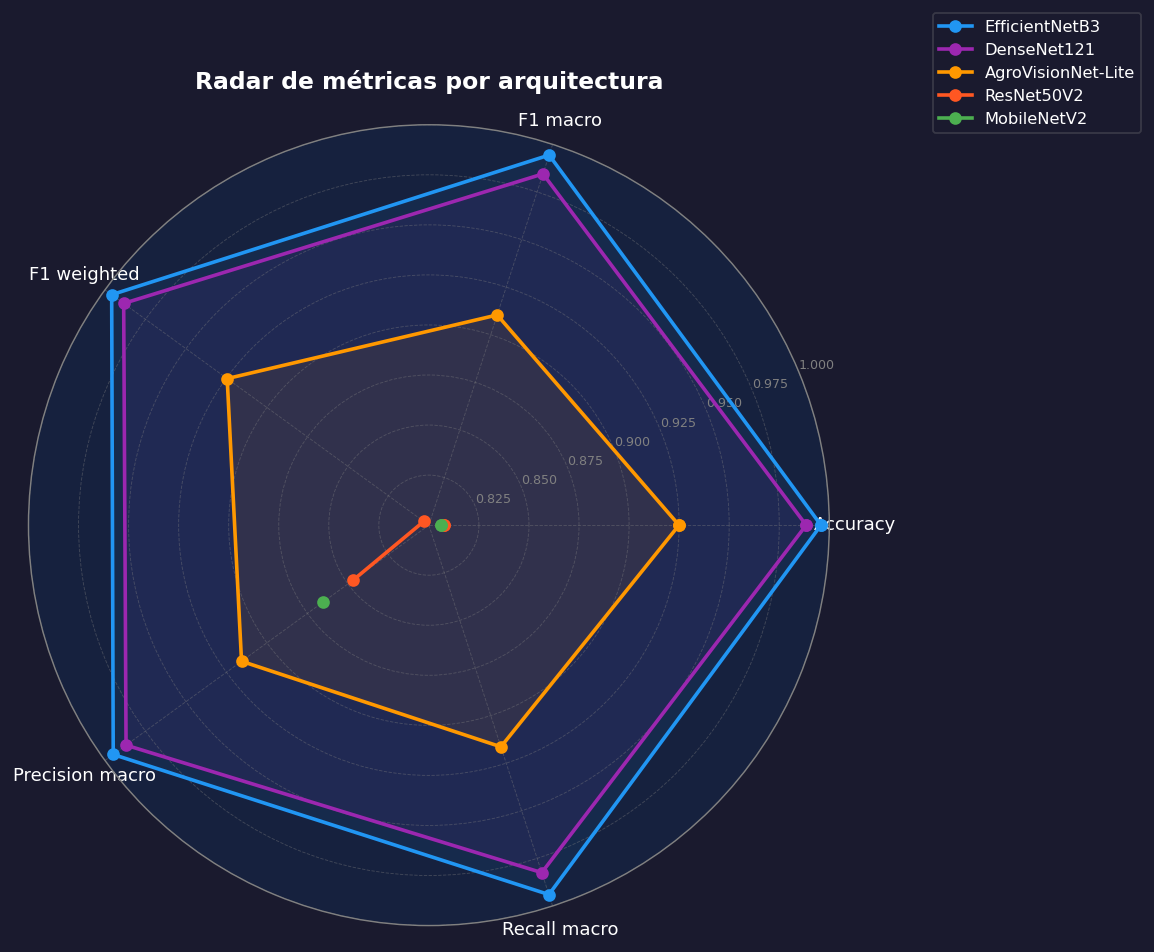

Guardado: C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\radar_modelos.png


In [8]:
from matplotlib.patches import FancyArrowPatch

categorias = ['Accuracy', 'F1 macro', 'F1 weighted', 'Precision macro', 'Recall macro']
columnas   = ['val_accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall']
N = len(categorias)

angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]   # cerrar el polígono
categorias_cierre = categorias + [categorias[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

for _, row in df_sorted.iterrows():
    nombre = row['modelo']
    valores_raw = [pd.to_numeric(row[c], errors='coerce') for c in columnas]
    if all(np.isnan(v) for v in valores_raw):
        continue
    # Rellenar NaN con 0
    valores_num = [v if not np.isnan(v) else 0.0 for v in valores_raw]
    valores_cierre = valores_num + [valores_num[0]]
    color = COLORES.get(nombre, '#607D8B')
    ax.plot(angulos, valores_cierre, 'o-', linewidth=2, color=color, label=nombre)
    ax.fill(angulos, valores_cierre, alpha=0.08, color=color)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, size=10, color='white')
ax.set_ylim(0.80, 1.00)
ax.yaxis.set_tick_params(labelcolor='gray', labelsize=7)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
ax.spines['polar'].set_color('gray')
ax.set_title('Radar de métricas por arquitectura', color='white',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15),
          framealpha=0.3, labelcolor='white', facecolor='#1a1a2e',
          edgecolor='gray', fontsize=9)

ruta_fig2 = os.path.join(OUTPUT_DIR, 'radar_modelos.png')
plt.savefig(ruta_fig2, bbox_inches='tight', dpi=150, facecolor='#1a1a2e')
plt.show()
print(f'Guardado: {ruta_fig2}')

## 7. Comparación Accuracy vs Loss (scatter)

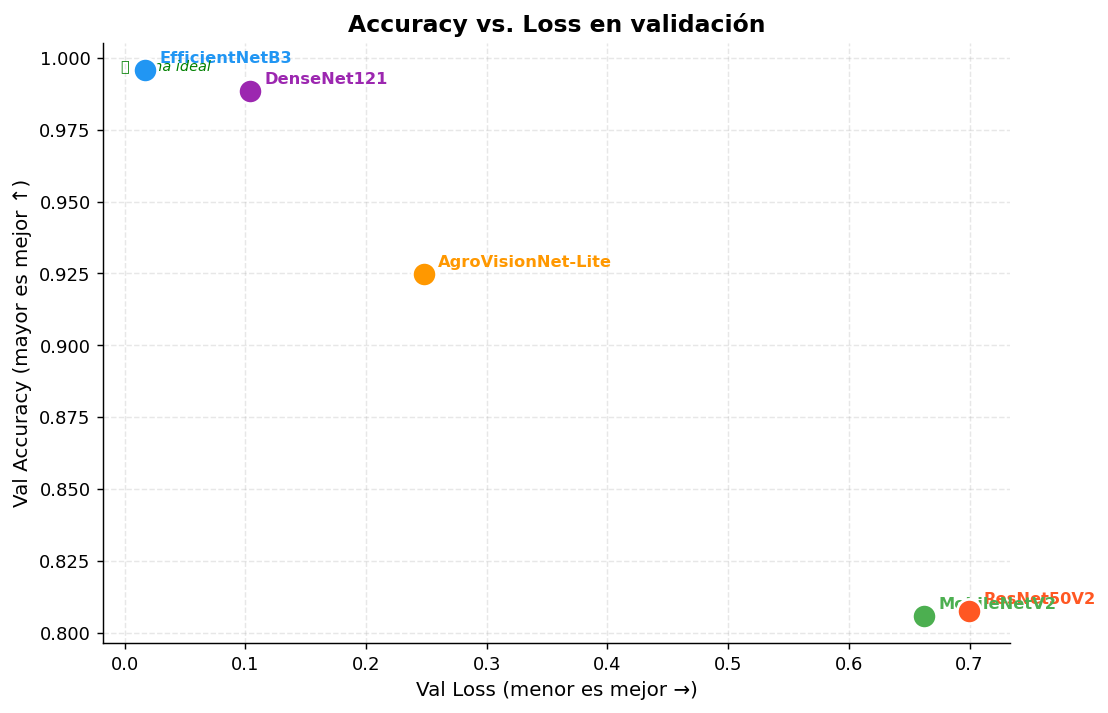

Guardado: C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\scatter_acc_vs_loss.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in df_sorted.iterrows():
    acc  = pd.to_numeric(row['val_accuracy'], errors='coerce')
    loss = pd.to_numeric(row['val_loss'], errors='coerce')
    nombre = row['modelo']
    color = COLORES.get(nombre, '#607D8B')
    if not (np.isnan(acc) or np.isnan(loss)):
        ax.scatter(loss, acc, color=color, s=180, zorder=5, edgecolors='white', linewidth=1.5)
        ax.annotate(nombre, (loss, acc), textcoords='offset points',
                    xytext=(8, 4), fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('Val Loss (menor es mejor →)', fontsize=11)
ax.set_ylabel('Val Accuracy (mayor es mejor ↑)', fontsize=11)
ax.set_title('Accuracy vs. Loss en validación', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')

# Cuadrante ideal: esquina superior izquierda
ax.annotate('⭐ Zona ideal', xy=(ax.get_xlim()[0], ax.get_ylim()[1]),
            xytext=(10, -15), textcoords='offset points',
            fontsize=8, color='green', fontstyle='italic')

ruta_fig3 = os.path.join(OUTPUT_DIR, 'scatter_acc_vs_loss.png')
plt.savefig(ruta_fig3, bbox_inches='tight', dpi=150)
plt.show()
print(f'Guardado: {ruta_fig3}')

## 8. Ranking por Score Compuesto

Puntuación ponderada que combina las métricas más importantes:
- **40%** Accuracy de validación
- **30%** F1-score macro
- **20%** F1-score weighted
- **10%** AUC macro (si disponible, si no se redistribuye)

In [10]:
def score_compuesto(row):
    acc  = pd.to_numeric(row['val_accuracy'],  errors='coerce')
    f1m  = pd.to_numeric(row['macro_f1'],      errors='coerce')
    f1w  = pd.to_numeric(row['weighted_f1'],   errors='coerce')
    auc  = pd.to_numeric(row['auc_macro'],     errors='coerce')

    tiene_auc = not np.isnan(auc)

    if tiene_auc:
        score = 0.40 * acc + 0.30 * f1m + 0.20 * f1w + 0.10 * auc
    else:
        # Redistribuir el 10% de AUC
        score = 0.45 * acc + 0.33 * f1m + 0.22 * f1w

    return round(score, 5) if not np.isnan(score) else np.nan

df['score_compuesto'] = df.apply(score_compuesto, axis=1)
df_rank = df.sort_values('score_compuesto', ascending=False).reset_index(drop=True)
df_rank.index += 1   # Ranking desde 1

print('=== RANKING FINAL POR SCORE COMPUESTO ===')
print()
medallas = ['🥇', '🥈', '🥉', '4️⃣ ', '5️⃣ ']
for i, row in df_rank.iterrows():
    medalla = medallas[i-1] if i <= 5 else f'{i}.'
    score   = row['score_compuesto']
    acc     = pd.to_numeric(row['val_accuracy'], errors='coerce')
    f1m     = pd.to_numeric(row['macro_f1'], errors='coerce')
    score_s = f'{score:.5f}' if not np.isnan(score) else 'N/A'
    acc_s   = f'{acc:.4f}'   if not np.isnan(acc)   else 'N/A'
    f1m_s   = f'{f1m:.4f}'  if not np.isnan(f1m)   else 'N/A'
    print(f'  {medalla}  {row["modelo"]:<22}  Score: {score_s}   Accuracy: {acc_s}   F1 macro: {f1m_s}')

mejor = df_rank.iloc[0]
print(f'\n🏆 MEJOR MODELO: {mejor["modelo"]}')
print(f'   Score compuesto: {mejor["score_compuesto"]:.5f}')

=== RANKING FINAL POR SCORE COMPUESTO ===

  🥇  EfficientNetB3          Score: 0.99582   Accuracy: 0.9958   F1 macro: 0.9944
  🥈  DenseNet121             Score: 0.98841   Accuracy: 0.9884   F1 macro: 0.9845
  🥉  AgroVisionNet-Lite      Score: 0.92791   Accuracy: 0.9249   F1 macro: 0.9104
  4️⃣   ResNet50V2              Score: 0.80757   Accuracy: 0.8076   F1 macro: 0.7486
  5️⃣   MobileNetV2             Score: 0.80487   Accuracy: 0.8059   F1 macro: 0.7516

🏆 MEJOR MODELO: EfficientNetB3
   Score compuesto: 0.99582


## 9. Gráfica de ranking final

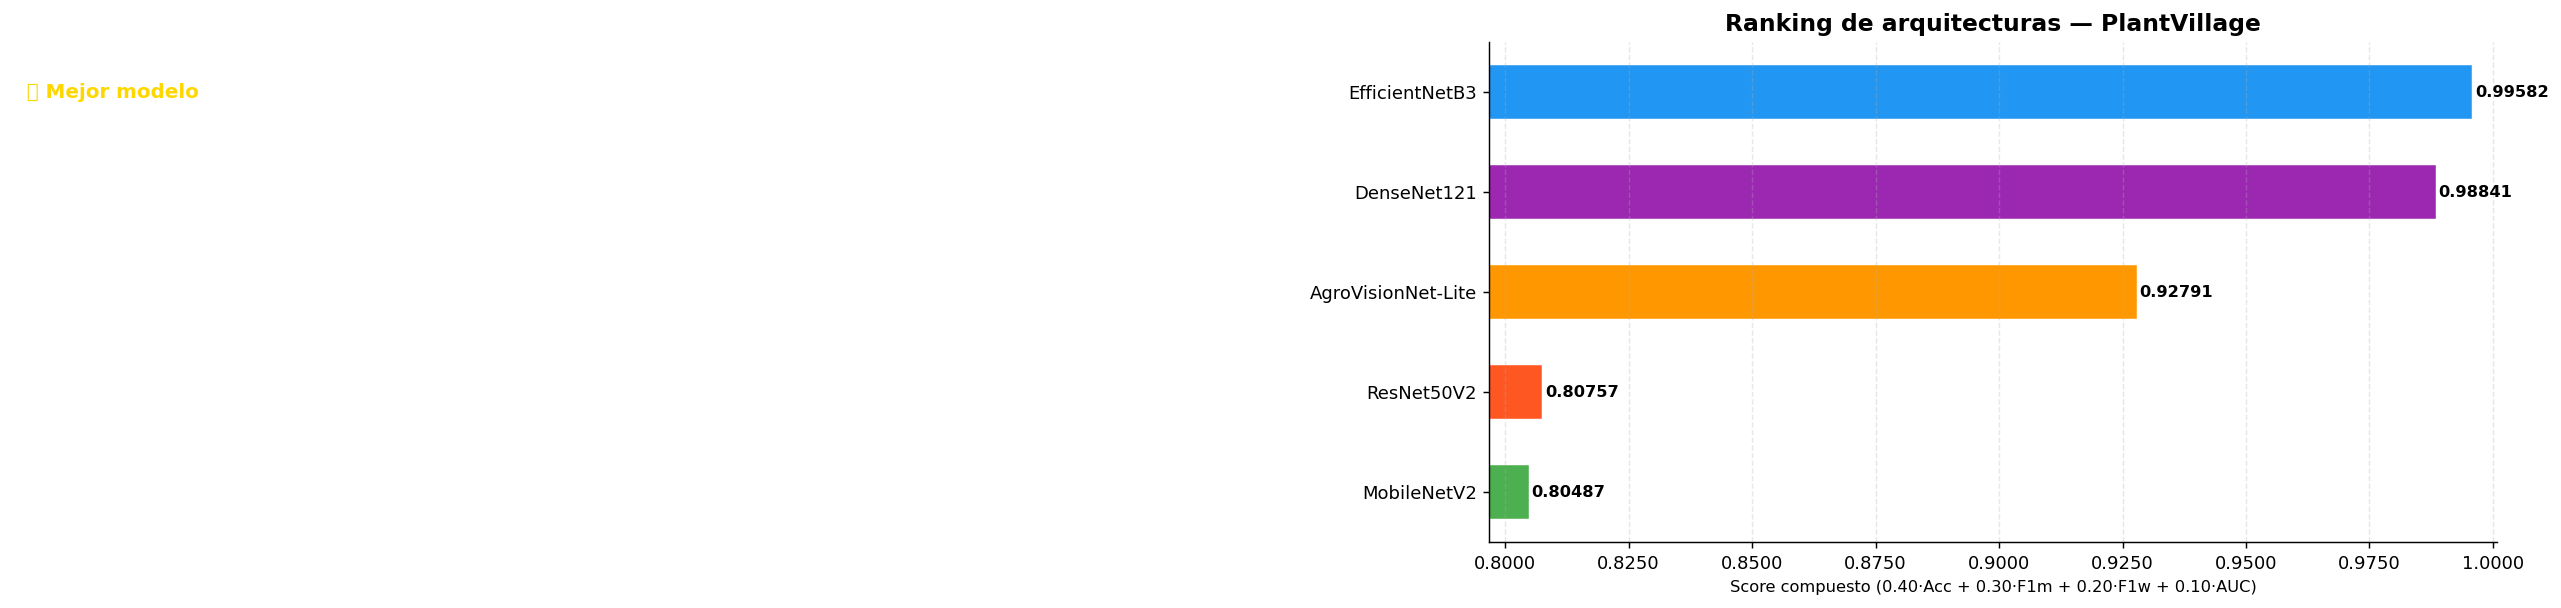

Guardado: C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\ranking_final.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

scores  = pd.to_numeric(df_rank['score_compuesto'], errors='coerce')
nombres = df_rank['modelo'].tolist()
colores_rank = [COLORES.get(n, '#607D8B') for n in nombres]

bars = ax.barh(nombres[::-1], scores[::-1], color=colores_rank[::-1],
               height=0.55, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, scores[::-1]):
    if not np.isnan(val):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.5f}', va='center', fontsize=9, fontweight='bold')

# Estrella al mejor
ax.text(scores.max() * 0.5, len(nombres) - 1,
        '  🏆 Mejor modelo', va='center', fontsize=11, color='gold', fontweight='bold')

ax.set_xlabel('Score compuesto (0.40·Acc + 0.30·F1m + 0.20·F1w + 0.10·AUC)', fontsize=9)
ax.set_title('Ranking de arquitecturas — PlantVillage', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
xlim_min = scores.dropna().min() * 0.99
xlim_max = scores.dropna().max() * 1.005
ax.set_xlim(xlim_min, xlim_max)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))

plt.tight_layout()
ruta_fig4 = os.path.join(OUTPUT_DIR, 'ranking_final.png')
plt.savefig(ruta_fig4, bbox_inches='tight', dpi=150)
plt.show()
print(f'Guardado: {ruta_fig4}')

## 10. Exportar resultados a CSV

In [12]:
ruta_csv = os.path.join(OUTPUT_DIR, 'comparacion_modelos.csv')
df_rank.to_csv(ruta_csv, index=True, float_format='%.6f')
print(f'✅ Tabla completa exportada a: {ruta_csv}')

# Resumen JSON
resumen = {
    'mejor_modelo':       str(df_rank.iloc[0]['modelo']),
    'score_compuesto':    float(df_rank.iloc[0]['score_compuesto']),
    'val_accuracy':       float(pd.to_numeric(df_rank.iloc[0]['val_accuracy'], errors='coerce')),
    'macro_f1':           float(pd.to_numeric(df_rank.iloc[0]['macro_f1'],     errors='coerce')),
    'ranking':            df_rank[['modelo', 'val_accuracy', 'macro_f1', 'score_compuesto']]
                              .to_dict(orient='records')
}

ruta_json = os.path.join(OUTPUT_DIR, 'resumen_comparacion.json')
with open(ruta_json, 'w') as f:
    json.dump(resumen, f, indent=2, default=str)
print(f'✅ Resumen JSON exportado a: {ruta_json}')

print('\n=== ARCHIVOS GENERADOS ===')
for archivo in os.listdir(OUTPUT_DIR):
    ruta_a = os.path.join(OUTPUT_DIR, archivo)
    tam = os.path.getsize(ruta_a)
    print(f'  {archivo:45s}  ({tam:,} bytes)')

✅ Tabla completa exportada a: C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\comparacion_modelos.csv
✅ Resumen JSON exportado a: C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos\resumen_comparacion.json

=== ARCHIVOS GENERADOS ===
  cache_h5.json                                  (819 bytes)
  comparacion_metricas.png                       (233,074 bytes)
  comparacion_modelos.csv                        (679 bytes)
  radar_modelos.png                              (251,972 bytes)
  ranking_final.png                              (75,509 bytes)
  resumen_comparacion.json                       (984 bytes)
  scatter_acc_vs_loss.png                        (75,692 bytes)


## 11. Conclusiones automáticas

In [13]:
mejor   = df_rank.iloc[0]
segundo = df_rank.iloc[1] if len(df_rank) > 1 else None

print('=' * 65)
print('                  CONCLUSIONES FINALES')
print('=' * 65)

print(f'\n📊 Dataset: PlantVillage — {int(df["num_clases"].dropna().max()) if df["num_clases"].dropna().any() else "N/A"} clases')
print(f'\n🏆 MEJOR ARQUITECTURA: {mejor["modelo"]}')
acc  = pd.to_numeric(mejor['val_accuracy'], errors='coerce')
f1m  = pd.to_numeric(mejor['macro_f1'],     errors='coerce')
f1w  = pd.to_numeric(mejor['weighted_f1'],  errors='coerce')
print(f'   • Accuracy   : {acc:.4f} ({acc*100:.2f}%)')
print(f'   • F1 macro   : {f1m:.4f}')
print(f'   • F1 weighted: {f1w:.4f}')
print(f'   • Score final: {mejor["score_compuesto"]:.5f}')

if segundo is not None:
    diff = mejor['score_compuesto'] - segundo['score_compuesto']
    print(f'\n   Diferencia con 2° lugar ({segundo["modelo"]}): +{diff:.5f}')

# Identificar arquitectura propia vs transferencia
agro = df_rank[df_rank['modelo'] == 'AgroVisionNet-Lite']
if not agro.empty:
    pos_agro = df_rank.index.get_loc(agro.index[0]) + 1
    acc_agro = pd.to_numeric(agro.iloc[0]['val_accuracy'], errors='coerce')
    acc_mejor= pd.to_numeric(mejor['val_accuracy'], errors='coerce')
    print(f'\n🔬 AgroVisionNet-Lite (arquitectura propia):')
    print(f'   • Posición en ranking: #{pos_agro} de {len(df_rank)}')
    if not np.isnan(acc_agro) and not np.isnan(acc_mejor):
        gap = abs(acc_mejor - acc_agro)
        if pos_agro == 1:
            print(f'   ✅ Supera a todos los modelos preentrenados.')
        else:
            print(f'   Diferencia con el mejor modelo: {gap*100:.2f} pp de accuracy')
            if gap < 0.02:
                print(f'   💡 Diferencia menor al 2% — resultado muy competitivo para arquitectura propia.')

print('\n' + '=' * 65)
print('Comparación finalizada. Gráficas y CSV guardados en:', OUTPUT_DIR)
print('=' * 65)

                  CONCLUSIONES FINALES

📊 Dataset: PlantVillage — 39 clases

🏆 MEJOR ARQUITECTURA: EfficientNetB3
   • Accuracy   : 0.9958 (99.58%)
   • F1 macro   : 0.9944
   • F1 weighted: 0.9958
   • Score final: 0.99582

   Diferencia con 2° lugar (DenseNet121): +0.00741

🔬 AgroVisionNet-Lite (arquitectura propia):
   • Posición en ranking: #3 de 5
   Diferencia con el mejor modelo: 7.09 pp de accuracy

Comparación finalizada. Gráficas y CSV guardados en: C:\Users\yenny\Documents\Universidad\IX Semestre\Aprendizaje Profundo\Proyecto\comparacion_modelos
